# Planning a Fast Rescue Boat Mission with an Extended Kalman Filter

## Roman Branovets, Skoltech, 2025

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt, atan, sin, cos, pi

### Trajectory generation

**True trajectory of boat path**

Generating a true trajectory of the coordinates $𝒙_𝒊$ and $y_i$ of an boat's motion. The trajectory
will consist of 500 points, starting with initial conditions $𝑥_0 = 1000 m$. ,$y_0 = 1000 m$., $𝑉_x = 10$ m/s, $𝑉_y = 10$ m/s. and a time
step $𝑇 = 1$ s.

$$
\begin{aligned}
x_i &= x_{i-1} + V_{i-1}^x T + \frac{a_{i-1}^x T^2}{2} \\
V_i^x &= V_{i-1}^x + a_{i-1}^x T \\
y_i &= y_{i-1} + V_{i-1}^y T + \frac{a_{i-1}^y T^2}{2} \\
V_i^y &= V_{i-1}^y + a_{i-1}^y T
\end{aligned}
$$

In [28]:
#generating_trajectory
steps=500
x_real=np.zeros(steps)
vx_real=np.zeros(steps)
y_real=np.zeros(steps)
vy_real=np.zeros(steps)
t=1
x_real[0]=1000
y_real[0]=1000
vx_real[0]=10
vy_real[0]=10
a=np.random.normal(0,0.3,steps)
for i in range(1,steps):
    x_real[i]=x_real[i-1]+vx_real[i-1]*t+(a[i-1]*(t**2))/2
    vx_real[i]=vx_real[i-1]+a[i-1]*t
    y_real[i]=y_real[i-1]+vy_real[i-1]*t+(a[i-1]*(t**2))/2
    vy_real[i]=vy_real[i-1]+a[i-1]*t

**True trajectory of boat path in polar coordinate system**

Generating the true values of range D (meters) and azimuth $\beta$ (radians)

$$
\begin{aligned}
D_i &= \sqrt{x_i^2 + y_i^2} \\
\beta_i &= \arctan\left(\frac{x_i}{y_i}\right)
\end{aligned}
$$

In [29]:
#trajectory_in_polar_coordinate_system
D_real=np.zeros(steps)
beta_real=np.zeros(steps)
for i in range(0,steps):
    D_real[i]=sqrt(x_real[i]**2 + y_real[i]**2)
    beta_real[i] = atan(x_real[i]/y_real[i])

Let's plot the motion in polar coordinate system

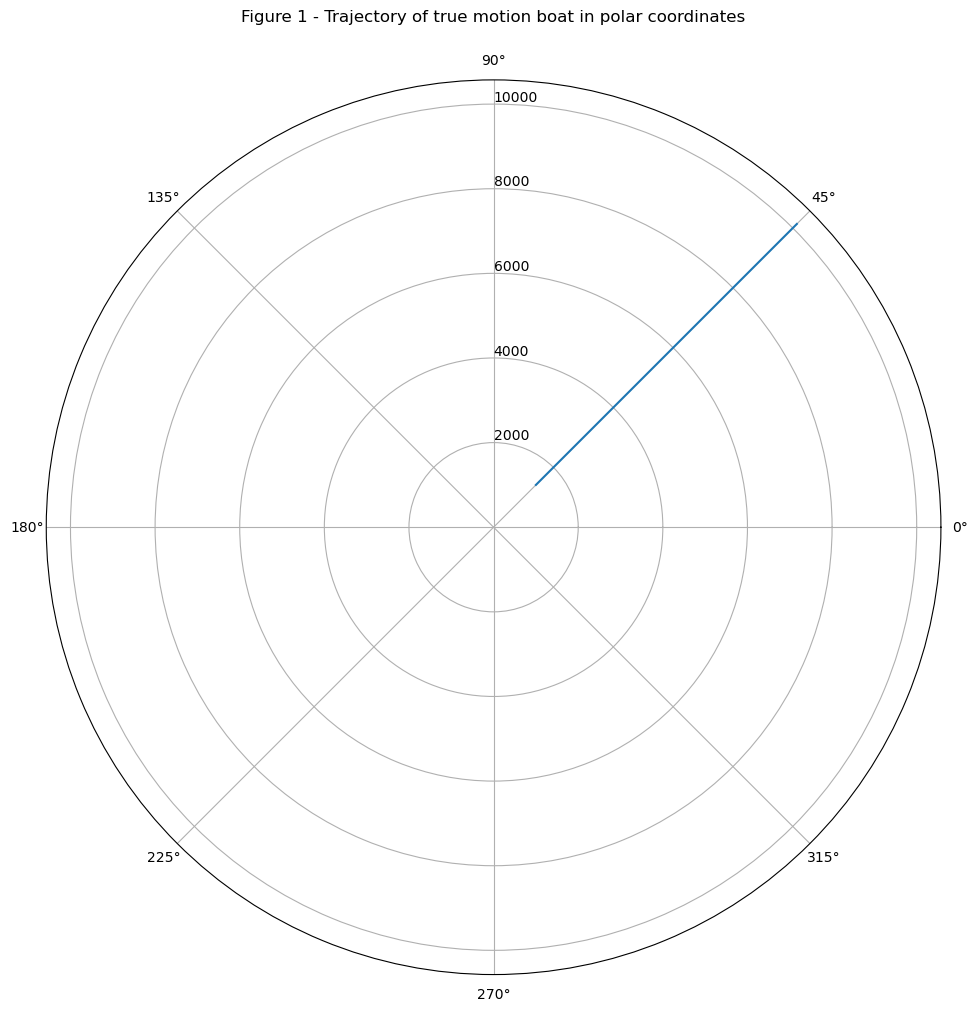

In [30]:
#polar_plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': 'polar'}, layout='constrained')
ax.plot(beta_real, D_real)
ax.grid(True)
ax.set_rlabel_position(90) 
ax.set_title("Figure 1 - Trajectory of true motion boat in polar coordinates", va='bottom',pad=40)
plt.show()

**Measurements**  
Generate measured values as follows:  

\
\begin{align*}
D_{i}^{m} &= D_{i} + \eta _{i}^{D} \\
\beta _{i}^{m} &= \beta _{i} + \eta _{i}^{\beta}
\end{align*}
\
$\eta _{i}^{D}$ and $\eta _{i}^{\beta }$ are variances of the measurement noises $\sigma _{D}$=50 m and $\sigma _{\beta}$ = 0.004 rad

In [31]:
#generating_measurements_of_polar
D=np.zeros(steps)
beta=np.zeros(steps)
for i in range(0,steps):
    D[i]=D_real[i]+np.random.normal(0,50)
    beta[i]=beta_real[i]+np.random.normal(0,0.004)

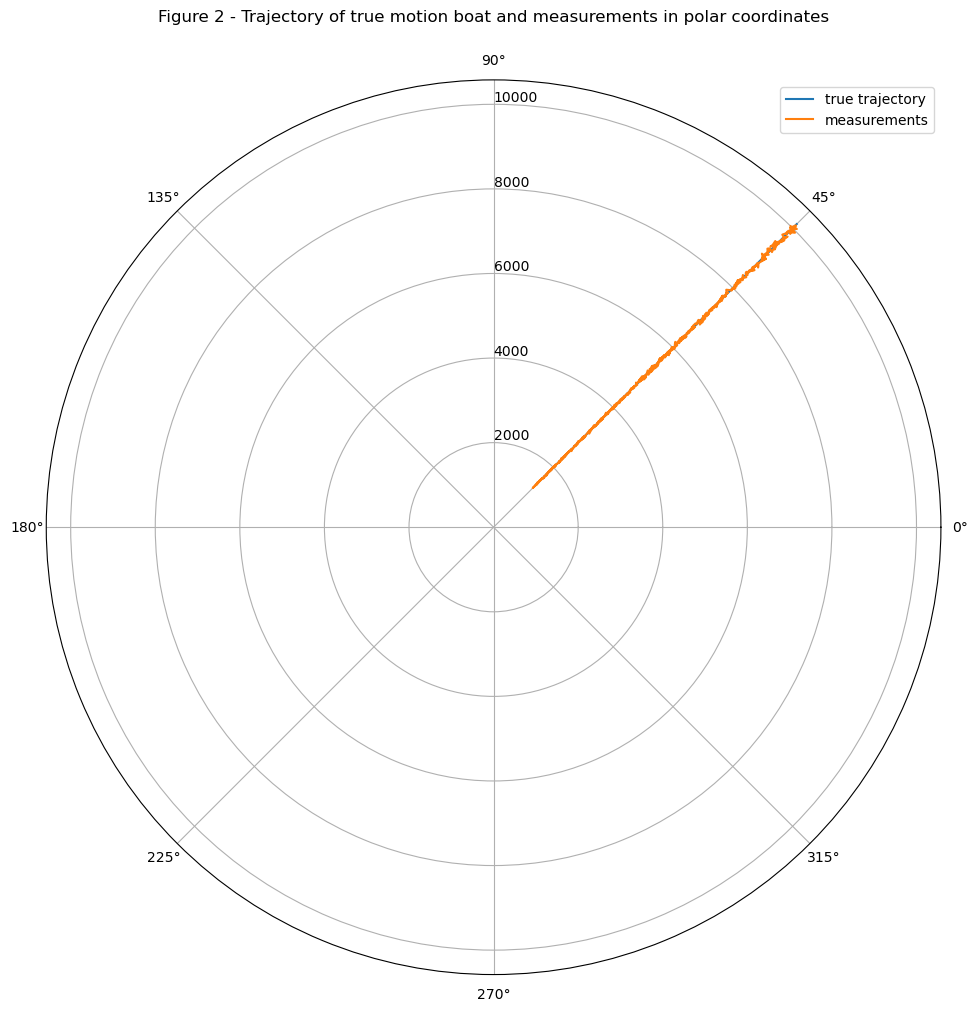

In [32]:
#polar_plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': 'polar'}, layout='constrained')
ax.plot(beta_real, D_real,label='true trajectory')
ax.plot(beta, D, label='measurements')
ax.grid(True)
ax.legend()
ax.set_rlabel_position(90) 
ax.set_title("Figure 2 - Trajectory of true motion boat and measurements in polar coordinates", va='bottom',pad=40)
plt.show()

Create the measurement vector z from measurements of range $D$ and azimuth $\beta$

In [33]:
z = np.zeros((steps, 2, 1))
for i in range(steps):
    z[i] = np.array([[D[i]], [beta[i]]])

**Extended Kalman Filter**  
Let's develop Extended Kalman Filter algorithm

In [34]:
#transition matrix
fi=np.matrix([[1,t,0,0],[0,1,0,0],[0,0,1,t],[0,0,0,1]])
#state vector
X = np.zeros((steps, 4, 1))
dh=np.zeros((steps,2,4))
h=np.zeros((steps,2,1))
#Initial filtered estimate
X[0]=np.matrix([[D[0]*sin(beta[0])],[0.0],[D[0]*cos(beta[0])],[0.0]])
#Filtration error covariance matrix
P=np.zeros((steps, 4, 4))
P[0]=np.matrix([[10**10, 0,0,0], [0, 10**10,0,0],[0,0,10**10,0],[0,0,0,10**10]])
D_pred=np.zeros(steps)
D_pred[0]=sqrt(X[0,0,0]**2+X[0,2,0]**2)
beta_pred=np.zeros(steps)
beta_pred[0]=atan(X[0,0,0]/X[0,2,0])
D_filt=np.zeros(steps)
D_filt[0]=sqrt(X[0,0,0]**2+X[0,2,0]**2)
beta_filt=np.zeros(steps)
beta_filt[0]=atan(X[0,0,0]/X[0,2,0])
#Covariance matrix
g=np.matrix([[(t**2)/2,0],[t,0],[0,(t**2)/2],[0,t]])
K = np.zeros((steps, 4, 2))
R=np.matrix([[50**2,0],[0,0.004*2]])
Q=np.matrix(g@g.T*(0.3**2))
for i in range(1,steps):
    #step of prediction
    X[i]=fi@X[i-1]
    P[i]=(fi@P[i-1]@fi.T)+Q
    D_pred[i]=sqrt(X[i,0,0]**2+X[i,2,0]**2)
    beta_pred[i]=atan(X[i,0,0]/X[i,2,0])
    #step of filtration
    h[i]=np.matrix([[sqrt(X[i,0,0]**2+X[i,2,0]**2)],[atan(X[i,0,0]/X[i,2,0])]])
    dh[i]=np.matrix([[X[i,0,0]/(sqrt(X[i,0,0]**2+X[i,2,0]**2)),0,X[i,2,0]/(sqrt(X[i,0,0]**2+X[i,2,0]**2)),0],[X[i,2,0]/(X[i,0,0]**2+X[i,2,0]**2),0,-X[i,0,0]/(X[i,0,0]**2+X[i,2,0]**2),0]])
    E=dh[i]@P[i]@dh[i].T + R
    K[i]=P[i]@dh[i].T@np.linalg.inv(E)
    X[i]=X[i]+K[i]@(z[i]-h[i])
    P[i]=(np.identity(4)-K[i]@dh[i])@P[i]
    D_filt[i]=sqrt(X[i,0,0]**2+X[i,2,0]**2)
    beta_filt[i]=atan(X[i,0,0]/X[i,2,0])

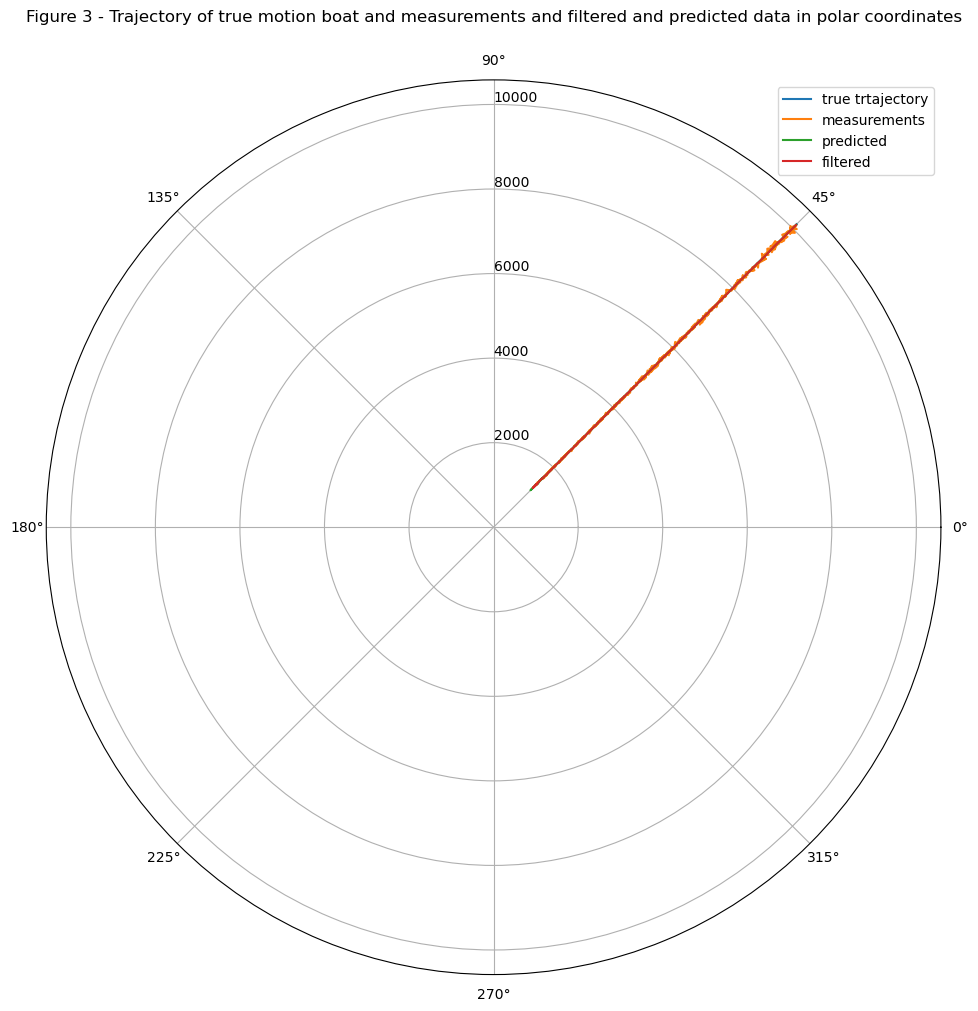

In [35]:
#polar_plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': 'polar'}, layout='constrained')
ax.plot(beta_real, D_real,label='true trtajectory')
ax.plot(beta, D, label='measurements')
ax.plot(beta_pred, D_pred, label='predicted')
ax.plot(beta_filt, D_filt, label='filtered')
ax.grid(True)
ax.legend()
ax.set_rlabel_position(90) 
ax.set_title("Figure 3 - Trajectory of true motion boat and measurements and filtered and predicted data in polar coordinates", va='bottom',pad=40)
plt.show()

Let's zoom-in a plot

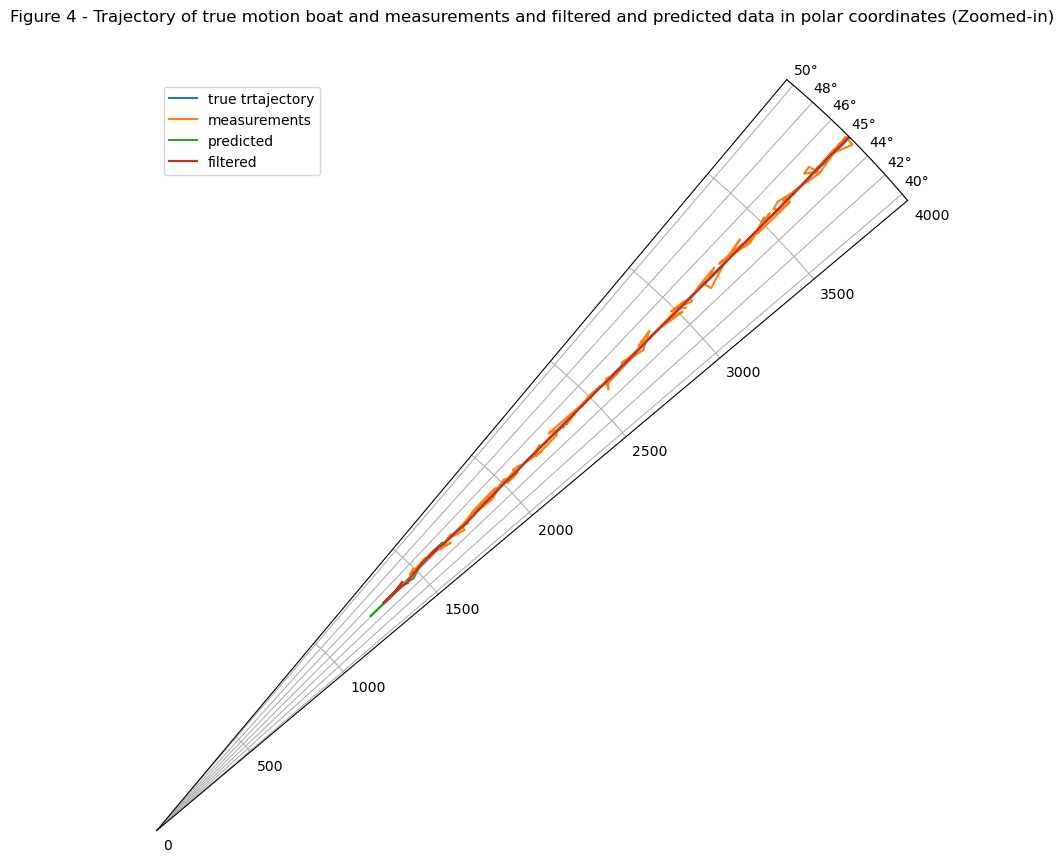

In [36]:
#polar_plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': 'polar'}, layout='constrained')
ax.plot(beta_real, D_real,label='true trtajectory')
ax.plot(beta, D, label='measurements')
ax.plot(beta_pred, D_pred, label='predicted')
ax.plot(beta_filt, D_filt, label='filtered')
ax.grid(True)
ax.legend()
ax.set_ylim(0,4000)
ax.set_xlim(40*pi/180,50*pi/180)
ax.set_rlabel_position(90) 
ax.set_title("Figure 4 - Trajectory of true motion boat and measurements and filtered and predicted data in polar coordinates (Zoomed-in)", va='bottom',pad=40)
plt.show()

As we can see, the Kalman filter stabilizes well and filters data efficiently when translating the coordinate system.

Run the Kalman Filter algorithm for M=500 iterations

In [37]:
#calculate error
M=500
steps=500
errordp=np.zeros((M,steps))
errorbp=np.zeros((M,steps))
fin_errdp=np.zeros(steps)
fin_errbp=np.zeros(steps)
errordf=np.zeros((M,steps))
errorbf=np.zeros((M,steps))
fin_errdf=np.zeros(steps)
fin_errbf=np.zeros(steps)
for o in range(M):
    #generating_trajectory
    steps=500
    x_real=np.zeros(steps)
    vx_real=np.zeros(steps)
    y_real=np.zeros(steps)
    vy_real=np.zeros(steps)
    t=1
    x_real[0]=1000
    y_real[0]=1000
    vx_real[0]=10
    vy_real[0]=10
    a=np.random.normal(0,0.3,steps)
    for i in range(1,steps):
        x_real[i]=x_real[i-1]+vx_real[i-1]*t+(a[i-1]*(t**2))/2
        vx_real[i]=vx_real[i-1]+a[i-1]*t
        y_real[i]=y_real[i-1]+vy_real[i-1]*t+(a[i-1]*(t**2))/2
        vy_real[i]=vy_real[i-1]+a[i-1]*t
    #trajectory_in_polar_coordinate_system
    D_real=np.zeros(steps)
    beta_real=np.zeros(steps)
    for i in range(0,steps):
        D_real[i]=sqrt(x_real[i]**2 + y_real[i]**2)
        beta_real[i] = atan(x_real[i]/y_real[i])
    #generating_measurements_of_polar
    D=np.zeros(steps)
    beta=np.zeros(steps)
    for i in range(0,steps):
        D[i]=D_real[i]+np.random.normal(0,50)
        beta[i]=beta_real[i]+np.random.normal(0,0.004)
    z = np.zeros((steps, 2, 1))
    for i in range(steps):
        z[i] = np.array([[D[i]], [beta[i]]])
    #transition matrix
    fi=np.matrix([[1,t,0,0],[0,1,0,0],[0,0,1,t],[0,0,0,1]])
    #state vector
    X = np.zeros((steps, 4, 1))
    dh=np.zeros((steps,2,4))
    h=np.zeros((steps,2,1))
    #Initial filtered estimate
    X[0]=np.matrix([[D[0]*sin(beta[0])],[0.0],[D[0]*cos(beta[0])],[0.0]])
    #Filtration error covariance matrix
    P=np.zeros((steps, 4, 4))
    P[0]=np.matrix([[10**10, 0,0,0], [0, 10**10,0,0],[0,0,10**10,0],[0,0,0,10**10]])
    D_pred=np.zeros(steps)
    D_pred[0]=sqrt(X[0,0,0]**2+X[0,2,0]**2)
    beta_pred=np.zeros(steps)
    beta_pred[0]=atan(X[0,0,0]/X[0,2,0])
    D_filt=np.zeros(steps)
    D_filt[0]=sqrt(X[0,0,0]**2+X[0,2,0]**2)
    beta_filt=np.zeros(steps)
    beta_filt[0]=atan(X[0,0,0]/X[0,2,0])
    #Covariance matrix
    g=np.matrix([[(t**2)/2,0],[t,0],[0,(t**2)/2],[0,t]])
    K = np.zeros((steps, 4, 2))
    R=np.matrix([[50**2,0],[0,0.004*2]])
    Q=np.matrix(g@g.T*(0.3**2))
    for i in range(1,steps):
        #step of prediction
        X[i]=fi@X[i-1]
        P[i]=(fi@P[i-1]@fi.T)+Q
        D_pred[i]=sqrt(X[i,0,0]**2+X[i,2,0]**2)
        beta_pred[i]=atan(X[i,0,0]/X[i,2,0])
        #step of filtration
        h[i]=np.matrix([[sqrt(X[i,0,0]**2+X[i,2,0]**2)],[atan(X[i,0,0]/X[i,2,0])]])
        #linearization
        dh[i]=np.matrix([[X[i,0,0]/(sqrt(X[i,0,0]**2+X[i,2,0]**2)),0,X[i,2,0]/(sqrt(X[i,0,0]**2+X[i,2,0]**2)),0],[X[i,2,0]/(X[i,0,0]**2+X[i,2,0]**2),0,-X[i,0,0]/(X[i,0,0]**2+X[i,2,0]**2),0]])
        E=dh[i]@P[i]@dh[i].T + R
        K[i]=P[i]@dh[i].T@np.linalg.inv(E)
        X[i]=X[i]+K[i]@(z[i]-h[i])
        P[i]=(np.identity(4)-K[i]@dh[i])@P[i]
        D_filt[i]=sqrt(X[i,0,0]**2+X[i,2,0]**2)
        beta_filt[i]=atan(X[i,0,0]/X[i,2,0])
    for k in range(2,steps):
        errordp[o,k]=(D_real[k]-D_pred[k])**2
        errorbp[o,k]=(beta_real[k]-beta_pred[k])**2
        errordf[o,k]=(D_real[k]-D_filt[k])**2
        errorbf[o,k]=(beta_real[k]-beta_filt[k])**2
for i in range(steps):
    for j in range(M):
        fin_errdp[i]=fin_errdp[i]+((1/(M-1))*errordp[j,i])
        fin_errbp[i]=fin_errbp[i]+((1/(M-1))*errorbp[j,i])
        fin_errdf[i]=fin_errdf[i]+((1/(M-1))*errordf[j,i])
        fin_errbf[i]=fin_errbf[i]+((1/(M-1))*errorbf[j,i])
    fin_errdp[i]=sqrt(fin_errdp[i])/50
    fin_errbp[i]=sqrt(fin_errbp[i])/0.004
    fin_errdf[i]=sqrt(fin_errdf[i])/50
    fin_errbf[i]=sqrt(fin_errbf[i])/0.004

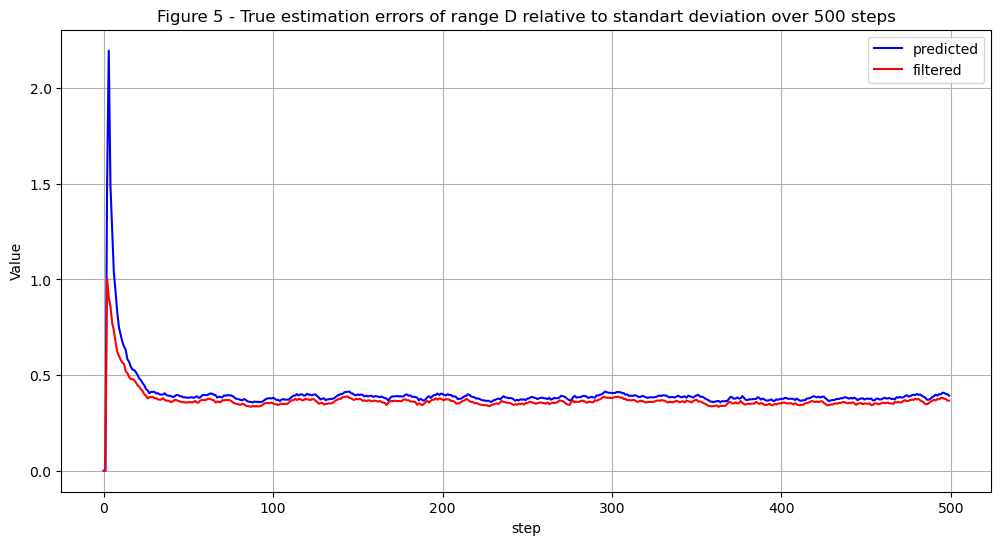

In [38]:
#Plot of the final error 
plt.figure(figsize=(12, 6))
plt.plot(fin_errdp, color="blue", label='predicted')
plt.plot(fin_errdf, color="red", label='filtered')
plt.title('Figure 5 - True estimation errors of range D relative to standart deviation over 500 steps')
plt.xlabel('step')
plt.ylabel('Value')
plt.grid()
plt.legend()
plt.show()

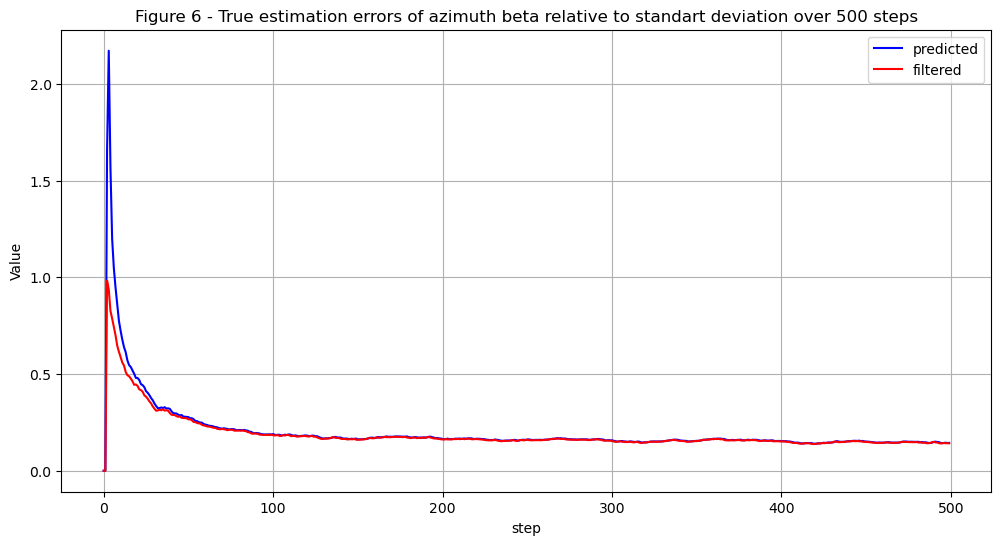

In [39]:
#Plot of the final error 
plt.figure(figsize=(12, 6))
plt.plot(fin_errbp, color="blue", label='predicted')
plt.plot(fin_errbf, color="red", label='filtered')
plt.title('Figure 6 - True estimation errors of azimuth beta relative to standart deviation over 500 steps')
plt.xlabel('step')
plt.ylabel('Value')
plt.grid()
plt.legend()
plt.show()

Over time, the error for both coordinates decreases, stabilizing at a value less than 1. Thus, the filter operates effectively and filters the data efficiently.

**Conclusion:**

Thus, we found out that when working with nonlinear models, the most effective option is to use an extended Kalman filter, which is able to linearize the model and deal with noise in this model.

**Learning log:**

What we learned:

We learned how to apply the extended Kalman filter and work with nonlinear models. We also found that the extended Kalman filter effectively filters noise.

What difficulties we faced:

We encountered difficulties in correctly setting the initial parameters of the extended Kalman filter. We also encountered difficulties in correctly formulating the calculation equations to ensure the matrix dimensions were correct.